### PSD Pipeline
#### Table of Contents:
* [1. Environment Setup](#1-environment-setup)
    * [1.1 Library Imports](#11-library-imports)
    * [1.2 Dataset loading/inspection](#12-dataset-loadinginspection)
* [2. Data Segmentation](#data-segmentation)
* [3. Feature Extraction and Class Distribution](#3-feature-extraction--class-distribution)
    * [3.1 DWT](#31-dwt-feature-extraction)
    * [3.2 Class Distribution](#32-class-distribution)
* [4. Classification Schemes](#4-classification-schemes)
    * [4.1 Emotional vs. Neutral](#41-emotional-vs-neutral-remap--class-distribution)
    * [4.2 Positive vs. Negative](#42-positive-vs-negative-remap--class-distribution)
* [5. Model Training](#5-model-training)
    * [5.1 XGBoost](#51-xgboost)
        * [Emotional vs. Neutral](#511-emotional-vs-neutral)




### 1. Environment Setup

##### 1.1 Library Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import loadmat
import pywt as pwt
from pywt import wavedec

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, balanced_accuracy_score, classification_report


/Users/connor/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### 1.2 Dataset loading/inspection

In [3]:
dataset_path = Path('DEED')
eeg_dataset = []
subject_ids = []

for file in dataset_path.iterdir():
    mat = loadmat(file)
    eeg = mat['Data']
    fname = file.stem  
    label_part = [part for part in fname.split("_") if part.startswith("E")][0]
    subject_part = [part for part in fname.split("_") if part.startswith("S")][0]
    label = int(label_part[1:])  
    subject_id = subject_part[1:-1]  # last two digits = subject number
    
    eeg_dataset.append((eeg, label))
    subject_ids.append(subject_id)

print(f"Loaded {len(eeg_dataset)} trials.")
print(f"Unique subjects: {len(set(subject_ids))}")
print(f"Subject IDs: {sorted(set(subject_ids))}")
print("Example shapes:", [(arr.shape, lbl) for arr, lbl in eeg_dataset[:3]])

print("\nSample filename → label mapping:")
for file, (_, label) in zip(dataset_path.iterdir(), eeg_dataset[:10]):
    print(f"  {file.stem} → E{label}")

Loaded 533 trials.
Unique subjects: 34
Subject IDs: ['002', '003', '004', '005', '007', '011', '012', '013', '014', '015', '016', '017', '018', '020', '021', '022', '023', '024', '025', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '042']
Example shapes: [((6, 290000), 2), ((6, 36000), 2), ((6, 51000), 3)]

Sample filename → label mapping:
  G_S0321_M1_E2_R1_N2_raw_ref → E2
  G_S0213_M3_E2_R7_N2_raw_ref → E2
  G_S0393_M2_E3_R5_REM_raw_ref → E3
  G_S0243_M3_E2_R2_N2_raw_ref → E2
  G_S0311_M3_E5_R2_N2_raw_ref → E5
  G_S0031_M1_E3_R4_nan_raw_ref → E3
  G_S0043_M2_E2_R5_N2_raw_ref → E2
  G_S0072_M1_E0_R11_N1_raw_ref → E0
  G_S0242_M1_E3_R3_W_raw_ref → E3
  G_S0342_M2_E3_R3_N2_raw_ref → E3


### 2. Data Segmentation

Done into 20s windows.

In [4]:
def segmentation(eeg_dataset, subject_ids, window_sec, fs):
    window_size = int(window_sec * fs)
    X = []
    y = []
    groups = []

    for (eeg_array, label), sid in zip(eeg_dataset, subject_ids):
        n_samples = eeg_array.shape[1]
        start = 0
        while start + window_size <= n_samples:
            window = eeg_array[:, start:start + window_size]
            X.append(window)
            y.append(label)
            groups.append(sid)
            start += window_size  

    return X, y, groups

windows, window_labels, window_groups = segmentation(eeg_dataset, subject_ids, 20, 200)
print(f"Total 20 second windows: {len(windows)}")
print(f"Unique subjects: {len(set(window_groups))}")

Total 20 second windows: 7490
Unique subjects: 34


### 3. Feature Extraction & Class Distribution

DWT features are extracted from each 20s window decomposed to level 5. For each channel, energy, variance, standard deviation, and peak amplitude are computed across all coefficient arrays, alongside hemispheric asymmetry features for each frontal, frontotemporal, and temporal channel pair, yielding 198 features per window.

##### 3.1 DWT Feature Extraction

In [5]:
CHANNELS = ['F3', 'F4', 'FT7', 'FT8', 'T7', 'T8']
ASYM_PAIRS = [(0, 1), (2, 3), (4, 5)]  # F3/F4, FT7/FT8, T7/T8

def extract_dwt_features(segmented_windows, labels):
    features = []
    for window in segmented_windows:
        channel_features = []
        channel_coeffs = []

        # Per-channel per-band stats
        for ch in range(window.shape[0]):
            coeffs = wavedec(window[ch], 'db4', level=5)
            channel_coeffs.append(coeffs)
            for coeff in coeffs:
                channel_features.extend([
                    np.mean(coeff),
                    np.std(coeff),
                    np.var(coeff),
                    np.sum(coeff**2),        # band energy
                    np.max(np.abs(coeff)),   # peak amplitude
                ])

        for left, right in ASYM_PAIRS:
            for level in range(6):  # 6 coefficient arrays at level=5
                left_energy = np.sum(channel_coeffs[left][level]**2)
                right_energy = np.sum(channel_coeffs[right][level]**2)
                asymmetry = (left_energy - right_energy) / (left_energy + right_energy + 1e-8)
                channel_features.append(asymmetry)

        features.append(channel_features)

    X = np.array(features)
    y = np.array(labels)
    return X, y


##### 3.2 Class Distribution

In [6]:
X, y = extract_dwt_features(windows, window_labels)
print(X.shape)
print(y.shape) 

print("\n=== Total Class Distribution===")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"E{label}: {count} windows ({count/len(y)*100:.1f}%)")

(7490, 198)
(7490,)

=== Total Class Distribution===
E0: 1294 windows (17.3%)
E1: 305 windows (4.1%)
E2: 1069 windows (14.3%)
E3: 2855 windows (38.1%)
E4: 1698 windows (22.7%)
E5: 269 windows (3.6%)


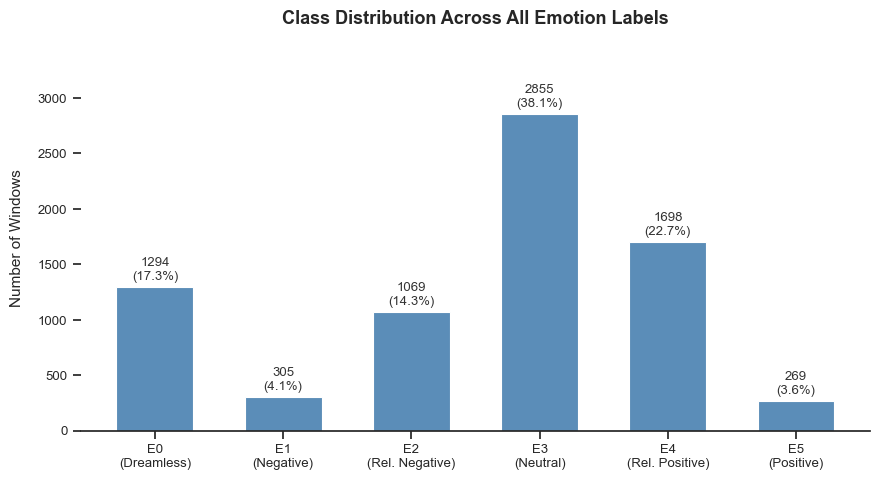

In [30]:
unique, counts = np.unique(y, return_counts=True)
total = len(y)

classes = ['E0\n(Dreamless)', 'E1\n(Negative)', 'E2\n(Rel. Negative)',
           'E3\n(Neutral)', 'E4\n(Rel. Positive)', 'E5\n(Positive)']

sns.set_theme(style="ticks", font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(classes, counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.6)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9.5, color='#333333')

ax.set_ylabel('Number of Windows', fontsize=11, labelpad=10)
ax.set_title('Class Distribution Across All Emotion Labels', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(counts) * 1.22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', labelsize=9.5)
ax.tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
plt.savefig('class_dist_full.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Classification Schemes

##### 4.1 Emotional vs. Neutral (remap + class distribution)  
Emotional {E1, E2, E4, E5} vs. Neutral Dream {E3} 

In [23]:
def remap_emotional_neutral(y):
    y = np.array(y)
    keep_mask = np.isin(y, [1, 2, 3, 4, 5])  
    new_y = np.zeros(len(y), dtype=int)
    new_y[np.isin(y, [1, 2, 4, 5])] = 1  
    return new_y[keep_mask], keep_mask

y_en, mask_en = remap_emotional_neutral(y)
X_en = X[mask_en]
groups_en = np.array(window_groups)[mask_en]

print(f"\n=== Emotional vs. Neutral Class Distribution ===")
print(f"  Total: {len(y_en)}")
print(f"  Neutral (0): {np.sum(y_en == 0)} ({np.sum(y_en == 0)/len(y_en)*100:.1f}%)")
print(f"  Emotional (1): {np.sum(y_en == 1)} ({np.sum(y_en == 1)/len(y_en)*100:.1f}%)")


=== Emotional vs. Neutral Class Distribution ===
  Total: 6196
  Neutral (0): 2855 (46.1%)
  Emotional (1): 3341 (53.9%)


In [24]:
# Subject Wise Class Distribution (EN)
print("=== Subject Wise Class Distribution (EN) ===")
for subject in sorted(set(groups_en)):
    mask = groups_en == subject
    labels = y_en[mask]
    unique = np.unique(labels)
    print(f"Subject {subject}: {len(labels)} windows, classes: {unique}, counts: {np.bincount(labels)}")

=== Subject Wise Class Distribution (EN) ===
Subject 002: 185 windows, classes: [0 1], counts: [ 18 167]
Subject 003: 400 windows, classes: [0 1], counts: [188 212]
Subject 004: 245 windows, classes: [0 1], counts: [104 141]
Subject 005: 242 windows, classes: [0 1], counts: [155  87]
Subject 007: 511 windows, classes: [0 1], counts: [ 78 433]
Subject 011: 43 windows, classes: [0], counts: [43]
Subject 012: 95 windows, classes: [0 1], counts: [83 12]
Subject 013: 26 windows, classes: [0 1], counts: [12 14]
Subject 014: 56 windows, classes: [0], counts: [56]
Subject 015: 269 windows, classes: [0 1], counts: [122 147]
Subject 016: 213 windows, classes: [0 1], counts: [184  29]
Subject 017: 213 windows, classes: [0 1], counts: [177  36]
Subject 018: 7 windows, classes: [0], counts: [7]
Subject 020: 105 windows, classes: [0 1], counts: [95 10]
Subject 021: 375 windows, classes: [0 1], counts: [162 213]
Subject 022: 207 windows, classes: [0 1], counts: [112  95]
Subject 023: 173 windows, cla

##### 4.2 Positive vs. Negative (remap + class distribution)
Positive {E4, E5} vs. Negative {E1, E2}

In [25]:
def remap_positive_negative(y):
    y = np.array(y)
    keep_mask = np.isin(y, [1, 2, 4, 5])  
    new_y = np.zeros(len(y), dtype=int)
    new_y[np.isin(y, [4, 5])] = 1  
    return new_y[keep_mask], keep_mask

y_pn, mask_pn = remap_positive_negative(y)
X_pn = X[mask_pn]
groups_pn = np.array(window_groups)[mask_pn]

print(f"\n=== Positive vs. Negative Class Distribution ===")
print(f"  Total: {len(y_pn)}")
print(f"  Negative (0): {np.sum(y_pn == 0)} ({np.sum(y_pn == 0)/len(y_pn)*100:.1f}%)")
print(f"  Positive (1): {np.sum(y_pn == 1)} ({np.sum(y_pn == 1)/len(y_pn)*100:.1f}%)")


=== Positive vs. Negative Class Distribution ===
  Total: 3341
  Negative (0): 1374 (41.1%)
  Positive (1): 1967 (58.9%)


In [26]:
# Subject Wise Class Distribution (PN)
print("=== Subject Wise Class Distribution (PN) ===")
for subject in sorted(set(groups_pn)):
    mask = groups_pn == subject
    labels = y_pn[mask]
    unique = np.unique(labels)
    print(f"Subject {subject}: {len(labels)} windows, classes: {unique}, counts: {np.bincount(labels)}")

=== Subject Wise Class Distribution (PN) ===
Subject 002: 167 windows, classes: [0 1], counts: [89 78]
Subject 003: 212 windows, classes: [0 1], counts: [ 65 147]
Subject 004: 141 windows, classes: [0 1], counts: [68 73]
Subject 005: 87 windows, classes: [0 1], counts: [33 54]
Subject 007: 433 windows, classes: [0 1], counts: [206 227]
Subject 012: 12 windows, classes: [0], counts: [12]
Subject 013: 14 windows, classes: [1], counts: [ 0 14]
Subject 015: 147 windows, classes: [0 1], counts: [ 22 125]
Subject 016: 29 windows, classes: [1], counts: [ 0 29]
Subject 017: 36 windows, classes: [0 1], counts: [28  8]
Subject 020: 10 windows, classes: [0], counts: [10]
Subject 021: 213 windows, classes: [0 1], counts: [ 28 185]
Subject 022: 95 windows, classes: [0 1], counts: [46 49]
Subject 023: 100 windows, classes: [0 1], counts: [21 79]
Subject 024: 235 windows, classes: [0 1], counts: [139  96]
Subject 025: 34 windows, classes: [1], counts: [ 0 34]
Subject 027: 26 windows, classes: [0 1], 

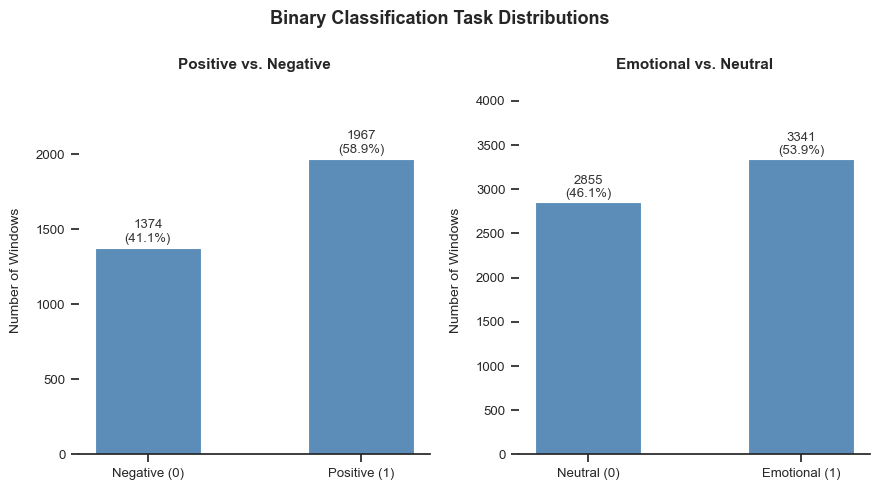

In [29]:
sns.set_theme(style="ticks", font_scale=1.1)
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(9, 5))

# Positive vs Negative
pn_counts = [np.sum(y_pn == 0), np.sum(y_pn == 1)]
pn_labels = ['Negative (0)', 'Positive (1)']
bars2 = ax2.bar(pn_labels, pn_counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.5)
for bar, count in zip(bars2, pn_counts):
    pct = count / sum(pn_counts) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9.5, color='#333333')
ax2.set_title('Positive vs. Negative', fontsize=11, fontweight='bold', pad=12)
ax2.set_ylabel('Number of Windows', fontsize=10, labelpad=10)
ax2.set_ylim(0, max(pn_counts) * 1.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='x', labelsize=9.5)
ax2.tick_params(axis='y', labelsize=9.5)

# Emotional vs Neutral
en_counts = [np.sum(y_en == 0), np.sum(y_en == 1)]
en_labels = ['Neutral (0)', 'Emotional (1)']
bars3 = ax3.bar(en_labels, en_counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.5)
for bar, count in zip(bars3, en_counts):
    pct = count / sum(en_counts) * 100
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9.5, color='#333333')
ax3.set_title('Emotional vs. Neutral', fontsize=11, fontweight='bold', pad=12)
ax3.set_ylabel('Number of Windows', fontsize=10, labelpad=10)
ax3.set_ylim(0, max(en_counts) * 1.25)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.tick_params(axis='x', labelsize=9.5)
ax3.tick_params(axis='y', labelsize=9.5)

fig.suptitle('Binary Classification Task Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_dist_binary.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Model Training
For both models and classification schemes, hyperparameters are optimized using Optuna with 5-fold StratifiedGroupKFold on the full dataset. The resulting best parameters are fixed and used for final evaluation with LOSO. For comparison, performance is also assessed using standard 10-fold cross-validation.

#### 5.1 XGBoost

##### General Functions for Training

In [ ]:
optuna.logging.set_verbosity(optuna.logging.INFO)

def hyperparameter_training(X, y, groups, model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'eval_metric':      'logloss',
        }
        cv = StratifiedGroupKFold(n_splits=5)
        scores = []
        for train_idx, val_idx in cv.split(X, y, groups):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            neg = np.sum(y_train == 0)
            pos = np.sum(y_train == 1)
            params['scale_pos_weight'] = neg/pos

            model = XGBClassifier(**params, n_jobs=-1, random_state = 42)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials = 50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")


    # Save best params
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    return best_params

In [13]:
def loso_loop(X, y, groups, params, model_name, classification_scheme):
    # LOSO evaluation with fixed params
    print(f"\n=== LOSO - {model_name} ({classification_scheme}) ===")
    logo = LeaveOneGroupOut()
    accs = []
    f1s = []
    aurocs = []
    bal_accs = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        if len(np.unique(y[test_idx])) < 2:
            continue

        subject = groups[test_idx[0]]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        #Per fold class weighting
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        fold_params = params.copy()
        fold_params['scale_pos_weight'] = neg/pos

        model = XGBClassifier(**fold_params)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))
        print(f"Subject {subject} | Balanced Accuracy: {bal_accs[-1]:.4f} | Accuracy: {accs[-1]:.4f} | F1: {f1s[-1]:.4f} | AUROC: {aurocs[-1]:.4f}")

    print(f"Balanced Accuracy:  {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"AUROC:  {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")


In [14]:
def ten_fold_cv_loop(X, y, params, model_name, classification_scheme):
    print(f"\n=== 10-Fold CV - {model_name} ({classification_scheme}) ===")
    # 10 Fold Cross CV with same tuned params
    cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    accs = []
    f1s = []
    bal_accs = []
    aurocs = []

    for train_idx, test_idx in cv_10fold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)
        fold_params = params.copy()
        fold_params['scale_pos_weight'] = neg / pos

        model = XGBClassifier(**fold_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))

    print(f"Accuracy:          {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:                {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"Balanced Accuracy: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"AUROC:             {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")

##### 5.1.1 Emotional vs. Neutral

In [13]:
#Hyperparameter tuning
xgb_en_params = hyperparameter_training(X_en, y_en, groups_en, "XGBoost", "Emotional vs. Neutral")

[I 2026-03-02 17:06:59,502] A new study created in memory with name: no-name-df77df10-c7a8-4ece-b779-f534524800eb


=== Hyperparameter Tuning - XGBoost (Emotional vs. Neutral) ===


[I 2026-03-02 17:07:12,534] Trial 0 finished with value: 0.508328650574666 and parameters: {'n_estimators': 403, 'max_depth': 7, 'learning_rate': 0.13464473430080434, 'subsample': 0.9107904139839289, 'colsample_bytree': 0.924938457219858, 'min_child_weight': 5, 'gamma': 3.232056563891525}. Best is trial 0 with value: 0.508328650574666.
[I 2026-03-02 17:07:23,235] Trial 1 finished with value: 0.5064900316474722 and parameters: {'n_estimators': 219, 'max_depth': 8, 'learning_rate': 0.11516414147419662, 'subsample': 0.9106391839780554, 'colsample_bytree': 0.6245165409720832, 'min_child_weight': 5, 'gamma': 1.72692557883326}. Best is trial 0 with value: 0.508328650574666.
[I 2026-03-02 17:07:34,427] Trial 2 finished with value: 0.4864263109398113 and parameters: {'n_estimators': 402, 'max_depth': 3, 'learning_rate': 0.017474627519253456, 'subsample': 0.7431194282035881, 'colsample_bytree': 0.8079820724695895, 'min_child_weight': 4, 'gamma': 4.47339654081956}. Best is trial 0 with value: 0.

Best params: {'n_estimators': 339, 'max_depth': 5, 'learning_rate': 0.22928895926088835, 'subsample': 0.7162742038681184, 'colsample_bytree': 0.916401296543453, 'min_child_weight': 4, 'gamma': 0.7743195220510344}
Best CV F1: 0.5264


In [14]:
#LOSO Evaluation
xgb_loso = loso_loop(X_en, y_en, groups_en, xgb_en_params, "XGBoost", "Emotional vs. Neutral")


=== LOSO - XGBoost (Emotional vs. Neutral) ===
Subject 002 | Balanced Accuracy: 0.5344 | Accuracy: 0.5622 | F1: 0.4415 | AUROC: 0.5805
Subject 003 | Balanced Accuracy: 0.4679 | Accuracy: 0.4625 | F1: 0.4604 | AUROC: 0.4832
Subject 004 | Balanced Accuracy: 0.4585 | Accuracy: 0.4653 | F1: 0.4582 | AUROC: 0.3900
Subject 005 | Balanced Accuracy: 0.5190 | Accuracy: 0.5744 | F1: 0.5176 | AUROC: 0.5371
Subject 007 | Balanced Accuracy: 0.5206 | Accuracy: 0.4814 | F1: 0.4281 | AUROC: 0.5263
Subject 012 | Balanced Accuracy: 0.6657 | Accuracy: 0.7895 | F1: 0.6242 | AUROC: 0.7309
Subject 013 | Balanced Accuracy: 0.6369 | Accuracy: 0.6154 | F1: 0.5938 | AUROC: 0.6429
Subject 015 | Balanced Accuracy: 0.4358 | Accuracy: 0.4275 | F1: 0.4262 | AUROC: 0.3796
Subject 016 | Balanced Accuracy: 0.5077 | Accuracy: 0.5258 | F1: 0.4385 | AUROC: 0.4631
Subject 017 | Balanced Accuracy: 0.5174 | Accuracy: 0.4554 | F1: 0.4195 | AUROC: 0.5314
Subject 020 | Balanced Accuracy: 0.6789 | Accuracy: 0.5810 | F1: 0.4867 

In [15]:
#10Fold CV
xgb_10f = ten_fold_cv_loop(X_en, y_en, xgb_en_params, "XGBoost", "Emotional vs. Neutral")


=== 10-Fold CV - XGBoost (Emotional vs. Neutral) ===
Accuracy:          0.6822 ± 0.0144
F1:                0.6797 ± 0.0147
Balanced Accuracy: 0.6795 ± 0.0147
AUROC:             0.7315 ± 0.0171


##### 5.1.2 Positive vs. Negative

In [16]:
#Hyperparameter tuning
xgb_pn_params = hyperparameter_training(X_pn, y_pn, groups_pn, "XGBoost", "Positive vs. Negative")

[I 2026-03-02 17:21:56,194] A new study created in memory with name: no-name-7bfd919e-70d9-41ad-8eb2-a16201a6edfd


=== Hyperparameter Tuning - XGBoost (Positive vs. Negative) ===


[I 2026-03-02 17:22:12,223] Trial 0 finished with value: 0.4827295476886698 and parameters: {'n_estimators': 408, 'max_depth': 5, 'learning_rate': 0.01381533316603648, 'subsample': 0.6661386325392359, 'colsample_bytree': 0.8731522155692457, 'min_child_weight': 9, 'gamma': 2.0791696173113716}. Best is trial 0 with value: 0.4827295476886698.
[I 2026-03-02 17:22:17,377] Trial 1 finished with value: 0.48036067607802246 and parameters: {'n_estimators': 124, 'max_depth': 7, 'learning_rate': 0.04527614160069201, 'subsample': 0.8285334551605561, 'colsample_bytree': 0.7888529906791529, 'min_child_weight': 10, 'gamma': 2.2956060894663843}. Best is trial 0 with value: 0.4827295476886698.
[I 2026-03-02 17:22:27,344] Trial 2 finished with value: 0.4864403584202062 and parameters: {'n_estimators': 531, 'max_depth': 5, 'learning_rate': 0.06741393927135964, 'subsample': 0.6633515058547114, 'colsample_bytree': 0.9728387653275103, 'min_child_weight': 2, 'gamma': 2.84068959452594}. Best is trial 2 with v

Best params: {'n_estimators': 386, 'max_depth': 5, 'learning_rate': 0.2589585705494989, 'subsample': 0.6315521193031983, 'colsample_bytree': 0.7067850488472216, 'min_child_weight': 9, 'gamma': 2.4774885155252213}
Best CV F1: 0.4990


In [17]:
#LOSO Evaluation
xgb_loso = loso_loop(X_pn, y_pn, groups_pn, xgb_pn_params, "XGBoost", "Positive vs. Negative")


=== LOSO - XGBoost (Positive vs. Negative) ===
Subject 002 | Balanced Accuracy: 0.5958 | Accuracy: 0.5928 | F1: 0.5928 | AUROC: 0.5847
Subject 003 | Balanced Accuracy: 0.3089 | Accuracy: 0.3868 | F1: 0.3165 | AUROC: 0.2802
Subject 004 | Balanced Accuracy: 0.5189 | Accuracy: 0.5248 | F1: 0.5081 | AUROC: 0.5612
Subject 005 | Balanced Accuracy: 0.5278 | Accuracy: 0.5747 | F1: 0.5256 | AUROC: 0.4428
Subject 007 | Balanced Accuracy: 0.4874 | Accuracy: 0.5012 | F1: 0.4492 | AUROC: 0.4850
Subject 015 | Balanced Accuracy: 0.4400 | Accuracy: 0.7483 | F1: 0.4280 | AUROC: 0.2255
Subject 017 | Balanced Accuracy: 0.5268 | Accuracy: 0.4722 | F1: 0.4515 | AUROC: 0.5580
Subject 021 | Balanced Accuracy: 0.4617 | Accuracy: 0.7230 | F1: 0.4644 | AUROC: 0.4691
Subject 022 | Balanced Accuracy: 0.5173 | Accuracy: 0.5158 | F1: 0.5153 | AUROC: 0.5506
Subject 023 | Balanced Accuracy: 0.3246 | Accuracy: 0.4300 | F1: 0.3396 | AUROC: 0.2911
Subject 024 | Balanced Accuracy: 0.4372 | Accuracy: 0.4085 | F1: 0.4050 

In [18]:
#10Fold CV
xgb_10f = ten_fold_cv_loop(X_pn, y_pn, xgb_pn_params, "XGBoost", "Positive vs. Negative")


=== 10-Fold CV - XGBoost (Positive vs. Negative) ===
Accuracy:          0.6492 ± 0.0184
F1:                0.6407 ± 0.0191
Balanced Accuracy: 0.6429 ± 0.0200
AUROC:             0.7223 ± 0.0263


#### 5.2 KNN (K-Nearest Neighbors)

##### General Functions for Training

In [31]:
optuna.logging.set_verbosity(optuna.logging.INFO)

def hyperparameter_training(X, y, groups, model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine']),
            'leaf_size': trial.suggest_int('leaf_size', 10, 50),
        }
        cv = StratifiedGroupKFold(n_splits=5)
        scores = []
        for train_idx, val_idx in cv.split(X, y, groups):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            groups_train = groups[train_idx]

            X_train_norm = X_train.copy()
            for subj in np.unique(groups_train):
                mask = groups_train == subj
                subj_scaler = StandardScaler()
                X_train_norm[mask] = subj_scaler.fit_transform(X_train[mask])

            val_scaler = StandardScaler()
            X_val_norm = val_scaler.fit_transform(X_val)

            model = KNeighborsClassifier(**params)
            model.fit(X_train_norm, y_train)
            preds = model.predict(X_val_norm)
            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials = 50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")


    # Save best params
    best_params = study.best_params
    return best_params

In [32]:
def loso_loop(X, y, groups, params, model_name, classification_scheme):
    # LOSO evaluation with fixed params
    print(f"\n=== LOSO - {model_name} ({classification_scheme}) ===")
    logo = LeaveOneGroupOut()
    accs = []
    f1s = []
    aurocs = []
    bal_accs = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        if len(np.unique(y[test_idx])) < 2:
            continue

        subject = groups[test_idx[0]]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        X_train_norm = X_train.copy()
        for subj in np.unique(groups_train):
            mask = groups_train == subj
            subj_scaler = StandardScaler()
            X_train_norm[mask] = subj_scaler.fit_transform(X_train[mask])

        test_scaler = StandardScaler()
        X_test_norm = test_scaler.fit_transform(X_test)

        model = KNeighborsClassifier(**params)
        model.fit(X_train_norm, y_train)
        preds = model.predict(X_test_norm)
        proba = model.predict_proba(X_test_norm)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))
        print(f"Subject {subject} | Balanced Accuracy: {bal_accs[-1]:.4f} | Accuracy: {accs[-1]:.4f} | F1: {f1s[-1]:.4f} | AUROC: {aurocs[-1]:.4f}")

    print(f"Balanced Accuracy:  {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"AUROC:  {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")


In [38]:
def ten_fold_cv_loop(X, y, params, model_name, classification_scheme):
    print(f"\n=== 10-Fold CV - {model_name} ({classification_scheme}) ===")
    # 10 Fold Cross CV with same tuned params
    cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    accs = []
    f1s = []
    bal_accs = []
    aurocs = []

    for train_idx, test_idx in cv_10fold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)  

        model = KNeighborsClassifier(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))

    print(f"Accuracy:          {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:                {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"Balanced Accuracy: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"AUROC:             {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")

##### 5.2.1 Emotional vs. Neutral

In [33]:
#Hyperparameter tuning
knn_en_params = hyperparameter_training(X_en, y_en, groups_en, "KNN", "Emotional vs. Neutral")

[I 2026-03-15 22:04:31,456] A new study created in memory with name: no-name-8590945a-3b29-4761-9420-6938c34c4be3


=== Hyperparameter Tuning - KNN (Emotional vs. Neutral) ===


[I 2026-03-15 22:04:40,687] Trial 0 finished with value: 0.5165440796951664 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'metric': 'cosine', 'leaf_size': 45}. Best is trial 0 with value: 0.5165440796951664.
[I 2026-03-15 22:04:42,565] Trial 1 finished with value: 0.44511289797042497 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'metric': 'manhattan', 'leaf_size': 43}. Best is trial 0 with value: 0.5165440796951664.
[I 2026-03-15 22:04:52,067] Trial 2 finished with value: 0.5123223182877246 and parameters: {'n_neighbors': 30, 'weights': 'uniform', 'metric': 'cosine', 'leaf_size': 12}. Best is trial 0 with value: 0.5165440796951664.
[I 2026-03-15 22:05:01,488] Trial 3 finished with value: 0.5085543758056239 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'metric': 'cosine', 'leaf_size': 31}. Best is trial 0 with value: 0.5165440796951664.
[I 2026-03-15 22:05:01,939] Trial 4 finished with value: 0.45033033584508536 and parameters: {'n_neighbors': 23, 'w

Best params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'cosine', 'leaf_size': 16}
Best CV F1: 0.5182


In [34]:
#LOSO Evaluation
knn_en_loso = loso_loop(X_en, y_en, groups_en, knn_en_params, "KNN", "Emotional vs. Neutral")


=== LOSO - KNN (Emotional vs. Neutral) ===
Subject 002 | Balanced Accuracy: 0.5015 | Accuracy: 0.5027 | F1: 0.4049 | AUROC: 0.5050
Subject 003 | Balanced Accuracy: 0.4819 | Accuracy: 0.4875 | F1: 0.4797 | AUROC: 0.4560
Subject 004 | Balanced Accuracy: 0.4678 | Accuracy: 0.4571 | F1: 0.4571 | AUROC: 0.4708
Subject 005 | Balanced Accuracy: 0.4481 | Accuracy: 0.4545 | F1: 0.4422 | AUROC: 0.4494
Subject 007 | Balanced Accuracy: 0.5026 | Accuracy: 0.3796 | F1: 0.3607 | AUROC: 0.5010
Subject 012 | Balanced Accuracy: 0.4257 | Accuracy: 0.4947 | F1: 0.3923 | AUROC: 0.4066
Subject 013 | Balanced Accuracy: 0.5833 | Accuracy: 0.5769 | F1: 0.5763 | AUROC: 0.7024
Subject 015 | Balanced Accuracy: 0.4776 | Accuracy: 0.4870 | F1: 0.4760 | AUROC: 0.4262
Subject 016 | Balanced Accuracy: 0.5248 | Accuracy: 0.6056 | F1: 0.4790 | AUROC: 0.5380
Subject 017 | Balanced Accuracy: 0.4866 | Accuracy: 0.4225 | F1: 0.3916 | AUROC: 0.5108
Subject 020 | Balanced Accuracy: 0.5263 | Accuracy: 0.3048 | F1: 0.2882 | AU

In [40]:
#10Fold CV
knn_en_10f = ten_fold_cv_loop(X_en, y_en, knn_en_params, "KNN", "Emotional vs. Neutral")


=== 10-Fold CV - KNN (Emotional vs. Neutral) ===
Accuracy:          0.6017 ± 0.0164
F1:                0.5953 ± 0.0176
Balanced Accuracy: 0.5956 ± 0.0173
AUROC:             0.6326 ± 0.0180


##### 5.2.2 Positive vs. Negative

In [35]:
#Hyperparameter tuning
knn_pn_params = hyperparameter_training(X_pn, y_pn, groups_pn, "KNN", "Positive vs. Negative")

[I 2026-03-15 22:11:56,045] A new study created in memory with name: no-name-68baf8d2-e42c-4743-87d1-d079cc8c15da


=== Hyperparameter Tuning - KNN (Positive vs. Negative) ===


[I 2026-03-15 22:11:58,808] Trial 0 finished with value: 0.4513602394612824 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'metric': 'cosine', 'leaf_size': 49}. Best is trial 0 with value: 0.4513602394612824.
[I 2026-03-15 22:11:58,966] Trial 1 finished with value: 0.4888247290836872 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 11}. Best is trial 1 with value: 0.4888247290836872.
[I 2026-03-15 22:11:59,121] Trial 2 finished with value: 0.4946109832765231 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 26}. Best is trial 2 with value: 0.4946109832765231.
[I 2026-03-15 22:11:59,839] Trial 3 finished with value: 0.4854050667423806 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'metric': 'manhattan', 'leaf_size': 21}. Best is trial 2 with value: 0.4946109832765231.
[I 2026-03-15 22:11:59,993] Trial 4 finished with value: 0.4888247290836872 and parameters: {'n_neighbors': 

Best params: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'manhattan', 'leaf_size': 39}
Best CV F1: 0.5164


In [36]:
#LOSO Evaluation
knn_pn_loso = loso_loop(X_pn, y_pn, groups_pn, knn_pn_params, "KNN", "Positive vs. Negative")


=== LOSO - KNN (Positive vs. Negative) ===
Subject 002 | Balanced Accuracy: 0.5725 | Accuracy: 0.5689 | F1: 0.5687 | AUROC: 0.5725
Subject 003 | Balanced Accuracy: 0.4848 | Accuracy: 0.5236 | F1: 0.4806 | AUROC: 0.4848
Subject 004 | Balanced Accuracy: 0.5321 | Accuracy: 0.5390 | F1: 0.5171 | AUROC: 0.5321
Subject 005 | Balanced Accuracy: 0.5539 | Accuracy: 0.5632 | F1: 0.5498 | AUROC: 0.5539
Subject 007 | Balanced Accuracy: 0.5028 | Accuracy: 0.5173 | F1: 0.4610 | AUROC: 0.5028
Subject 015 | Balanced Accuracy: 0.5220 | Accuracy: 0.5374 | F1: 0.4556 | AUROC: 0.5220
Subject 017 | Balanced Accuracy: 0.4018 | Accuracy: 0.4167 | F1: 0.3778 | AUROC: 0.4018
Subject 021 | Balanced Accuracy: 0.5777 | Accuracy: 0.4507 | F1: 0.4130 | AUROC: 0.5777
Subject 022 | Balanced Accuracy: 0.6009 | Accuracy: 0.6000 | F1: 0.6000 | AUROC: 0.6009
Subject 023 | Balanced Accuracy: 0.4135 | Accuracy: 0.4600 | F1: 0.3984 | AUROC: 0.4135
Subject 024 | Balanced Accuracy: 0.4968 | Accuracy: 0.4638 | F1: 0.4595 | AU

In [39]:
#10Fold CV
#Most likely worse due to class imbalance
knn_pn_10f = ten_fold_cv_loop(X_pn, y_pn, knn_pn_params, "KNN", "Positive vs. Negative")


=== 10-Fold CV - KNN (Positive vs. Negative) ===
Accuracy:          0.6372 ± 0.0119
F1:                0.6288 ± 0.0149
Balanced Accuracy: 0.6311 ± 0.0165
AUROC:             0.6311 ± 0.0165


### Appendix